# 🔶 Case Study 3: Forecasting Future Headcount & Turnover Impact
🔸 "Based on current attrition rates and hiring pace, project the headcount by department for the next 6 months. Identify risk areas and make recommendations."
What You’ll Likely Do:
* Calculate attrition rate by month and department
* Build a simple forecasting model (e.g., moving average, linear extrapolation)
* Model a few scenarios (e.g., What if attrition increases by 5%?)
* Visualize future headcount trend
What to Prepare:
* Time series handling (pd.to_datetime, resample, rolling)
* Scenario analysis
* Plotting future values
Business storytelling: “If current trends continue, Department X will be understaffed by July

## Load and Exploration

In [125]:
#importing all libariries

import pandas as pd 
import numpy as np
from datetime import datetime
from dateutil import parser
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
plt.rcParams['figure.figsize']=(12,6)
plt.gca().set_facecolor('whitesmoke')
plt.grid(color='lightgray', linestyle='-', linewidth=0.5)

In [6]:
#Load

Em = pd.read_csv('employees.csv')
print("Emplyee Data Loaded Successfully")
Hr = pd.read_csv('hiring_data.csv')
print("Hiring Data Loaded Successfully")
Tn = pd.read_csv('termination_data.csv')
print("Termination Data Loaded Successfully")
Hc = pd.read_csv('monthly_headcount.csv')
print("Monthly Data Loaded Successfully")

Emplyee Data Loaded Successfully
Hiring Data Loaded Successfully
Termination Data Loaded Successfully
Monthly Data Loaded Successfully


In [15]:
#exploration

print(Em.shape)
print(Hr.shape)
print(Tn.shape)
print(Hc.shape)


(152, 7)
(3, 5)
(26, 5)
(126, 8)


In [17]:
Em.head()

,employee_id,department,hire_date,tenure_months,salary,performance_rating,remote_status
0,1000,Engineering,2020-07-25,29.237845,87616.147407,4,Hybrid
1,1001,Engineering,2022-01-06,11.826544,70228.553456,4,Hybrid
2,1002,Engineering,2020-07-14,29.599212,70746.827990,3,Hybrid
3,1003,Engineering,2022-11-11,1.675427,71582.452892,3,Remote
4,1004,Engineering,2021-08-15,16.557162,64267.533195,4,Hybrid


In [19]:
Hr.head()

,employee_id,department,hire_date,salary,source
0,1152,HR,2023-02-11,87216.865771,Referral
1,1153,HR,2023-11-13,87760.661047,LinkedIn
2,1154,Customer Success,2024-02-18,107761.593076,Referral


In [21]:
Tn.head()

,employee_id,department,termination_date,reason,tenure_months
0,1078,Marketing,2023-04-20,Voluntary - Better Opportunity,20.594544
1,1136,Finance,2023-04-18,Voluntary - Better Opportunity,23.625925
2,1028,Engineering,2023-05-08,Layoff,24.989473
3,1063,Sales,2023-05-27,Performance,42.921228
4,1026,Engineering,2023-07-23,Voluntary - Better Opportunity,4.119129


In [23]:
Hc.head()

,date,department,hires,terminations,starting_headcount,ending_headcount,attrition_rate,growth_rate
0,2023-01-01,Engineering,0,0,45,45,0.0,0.0
1,2023-01-01,Sales,0,0,32,32,0.0,0.0
2,2023-01-01,Marketing,0,0,18,18,0.0,0.0
3,2023-01-01,Customer Success,0,0,22,22,0.0,0.0
4,2023-01-01,HR,0,0,8,8,0.0,0.0


In [25]:
Em.describe()

,employee_id,tenure_months,salary,performance_rating
count,152.000000,152.000000,152.000000,152.000000
mean,1075.500000,18.264792,80965.073164,4.006579
std,44.022721,10.824313,16862.898351,0.645891
min,1000.000000,1.116951,29684.146598,3.000000
25%,1037.750000,9.781537,70659.209938,4.000000
50%,1075.500000,17.214192,81485.693758,4.000000
75%,1113.250000,27.997700,93042.230221,4.000000
max,1151.000000,35.775296,132579.866868,5.000000


In [27]:
Em.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 152 entries, 0 to 151
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         152 non-null    int64  
 1   department          152 non-null    object 
 2   hire_date           152 non-null    object 
 3   tenure_months       152 non-null    float64
 4   salary              152 non-null    float64
 5   performance_rating  152 non-null    int64  
 6   remote_status       152 non-null    object 
dtypes: float64(2), int64(2), object(3)
memory usage: 8.4+ KB


In [29]:
Tn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26 entries, 0 to 25
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   employee_id       26 non-null     int64  
 1   department        26 non-null     object 
 2   termination_date  26 non-null     object 
 3   reason            26 non-null     object 
 4   tenure_months     26 non-null     float64
dtypes: float64(1), int64(1), object(3)
memory usage: 1.1+ KB


In [31]:
Hc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 126 entries, 0 to 125
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   date                126 non-null    object 
 1   department          126 non-null    object 
 2   hires               126 non-null    int64  
 3   terminations        126 non-null    int64  
 4   starting_headcount  126 non-null    int64  
 5   ending_headcount    126 non-null    int64  
 6   attrition_rate      126 non-null    float64
 7   growth_rate         126 non-null    float64
dtypes: float64(2), int64(4), object(2)
memory usage: 8.0+ KB


In [33]:
Hr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   employee_id  3 non-null      int64  
 1   department   3 non-null      object 
 2   hire_date    3 non-null      object 
 3   salary       3 non-null      float64
 4   source       3 non-null      object 
dtypes: float64(1), int64(1), object(3)
memory usage: 252.0+ bytes


In [44]:
Em['hire_date'].min()
print(Em['hire_date'].min())
Em['hire_date'].max()
print(Em['hire_date'].max())

2020-01-08
2022-11-28


In [54]:
Tn.duplicated().sum()

0

# Observation 1: Data Exploration:

1. we have four dataset (Employee(152, 7), Headcount((126, 8)), Termination((26, 5)),Hiring count(3, 5)
2. Mix of numeric, cat,date cols
3. Date has to change the datatype
4. 2.5 years of data
5. No Duplicates
6. Possible outliars in salary

## Data Cleaning

In [57]:
Em.isna().sum()

employee_id           0
department            0
hire_date             0
tenure_months         0
salary                0
performance_rating    0
remote_status         0
dtype: int64

In [59]:
Tn.isna().sum()

employee_id         0
department          0
termination_date    0
reason              0
tenure_months       0
dtype: int64

In [61]:
Hc.isna().sum()

date                  0
department            0
hires                 0
terminations          0
starting_headcount    0
ending_headcount      0
attrition_rate        0
growth_rate           0
dtype: int64

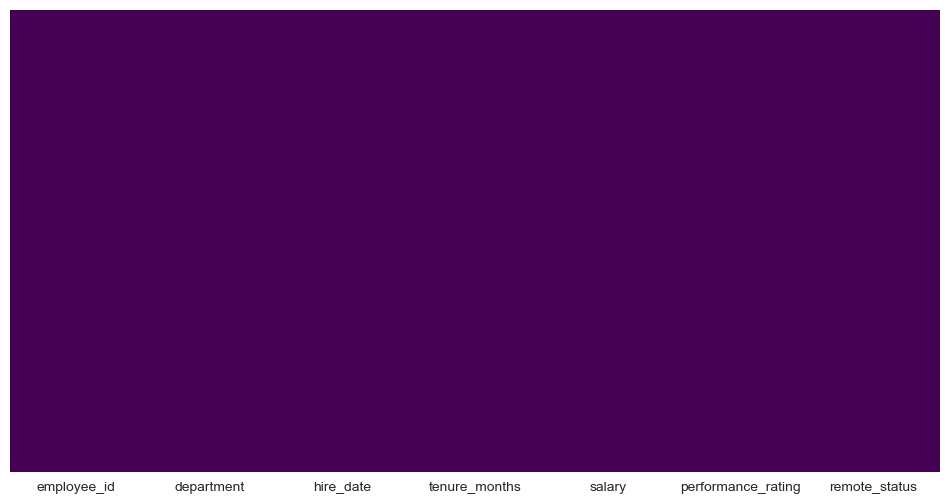

In [87]:
sns.heatmap(Em.isna(),cbar=False,yticklabels=False,cmap='viridis')
plt.show()

In [63]:
Hr.isna().sum()

employee_id    0
department     0
hire_date      0
salary         0
source         0
dtype: int64

In [65]:
Em.columns

Index(['employee_id', 'department', 'hire_date', 'tenure_months', 'salary',
       'performance_rating', 'remote_status'],
      dtype='object')

In [67]:
Em['hire_date']

0      2020-07-25
1      2022-01-06
2      2020-07-14
3      2022-11-11
4      2021-08-15
          ...    
147    2020-09-18
148    2021-08-05
149    2022-07-30
150    2022-11-08
151    2022-08-14
Name: hire_date, Length: 152, dtype: object

In [69]:
Em['hire_date']=pd.to_datetime(Em['hire_date'],yearfirst=True,errors='coerce')

In [71]:
Em['hire_date']

0     2020-07-25
1     2022-01-06
2     2020-07-14
3     2022-11-11
4     2021-08-15
         ...    
147   2020-09-18
148   2021-08-05
149   2022-07-30
150   2022-11-08
151   2022-08-14
Name: hire_date, Length: 152, dtype: datetime64[ns]

In [73]:
Tn.columns

Index(['employee_id', 'department', 'termination_date', 'reason',
       'tenure_months'],
      dtype='object')

In [77]:
Tn['termination_date'].head(4)

0    2023-04-20
1    2023-04-18
2    2023-05-08
3    2023-05-27
Name: termination_date, dtype: object

In [79]:
Tn['termination_date']=pd.to_datetime(Tn['termination_date'],yearfirst=True,errors='coerce')

In [81]:
Tn['termination_date'].head(4)

0   2023-04-20
1   2023-04-18
2   2023-05-08
3   2023-05-27
Name: termination_date, dtype: datetime64[ns]

In [175]:
Hc['date']=pd.to_datetime(Hc['date'],yearfirst=True,errors='coerce')

In [83]:
Em['department'].unique()

array(['Engineering', 'Sales', 'Marketing', 'Customer Success', 'HR',
       'Finance', 'Operations'], dtype=object)

## Observation:2 Data Cleaning 

1. Chaged the hire_date and termination_date in date data types
2. No Missing Values
3. No Duplicates
4. Consistant formatting

## Explorartory Data Analysis

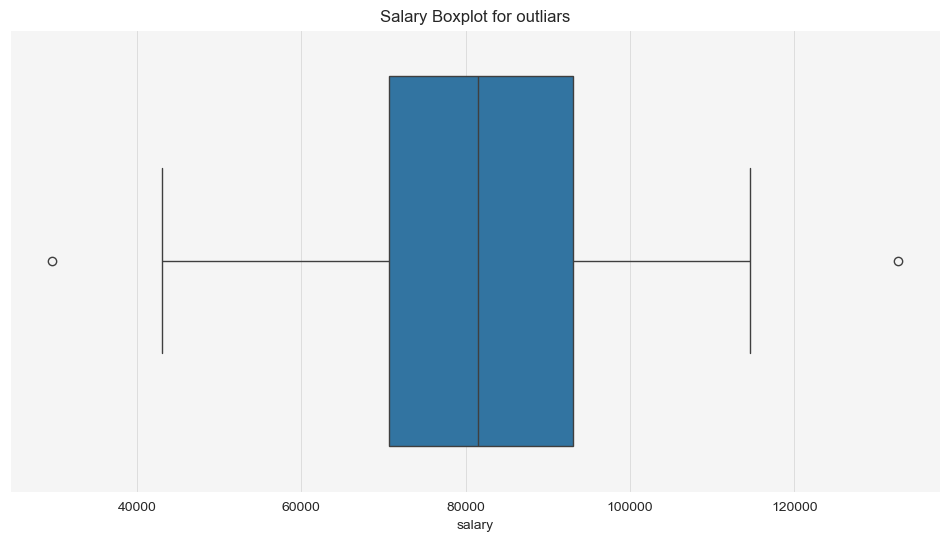

In [127]:
#check outliars

sns.boxplot(x=Em['salary'])
plt.title('Salary Boxplot for outliars')
plt.show()

In [91]:
Em.columns

Index(['employee_id', 'department', 'hire_date', 'tenure_months', 'salary',
       'performance_rating', 'remote_status'],
      dtype='object')

In [231]:
Em.describe()

,employee_id,hire_date,tenure_months,salary,performance_rating
count,152.000000,152,152.000000,152.000000,152.000000
mean,1075.500000,2021-06-24 00:28:25.263158016,18.264792,80965.073164,4.006579
min,1000.000000,2020-01-08 00:00:00,1.116951,29684.146598,3.000000
25%,1037.750000,2020-08-31 18:00:00,9.781537,70659.209938,4.000000
50%,1075.500000,2021-07-26 00:00:00,17.214192,81485.693758,4.000000
75%,1113.250000,2022-03-09 06:00:00,27.997700,93042.230221,4.000000
max,1151.000000,2022-11-28 00:00:00,35.775296,132579.866868,5.000000
std,44.022721,NaN,10.824313,16862.898351,0.645891


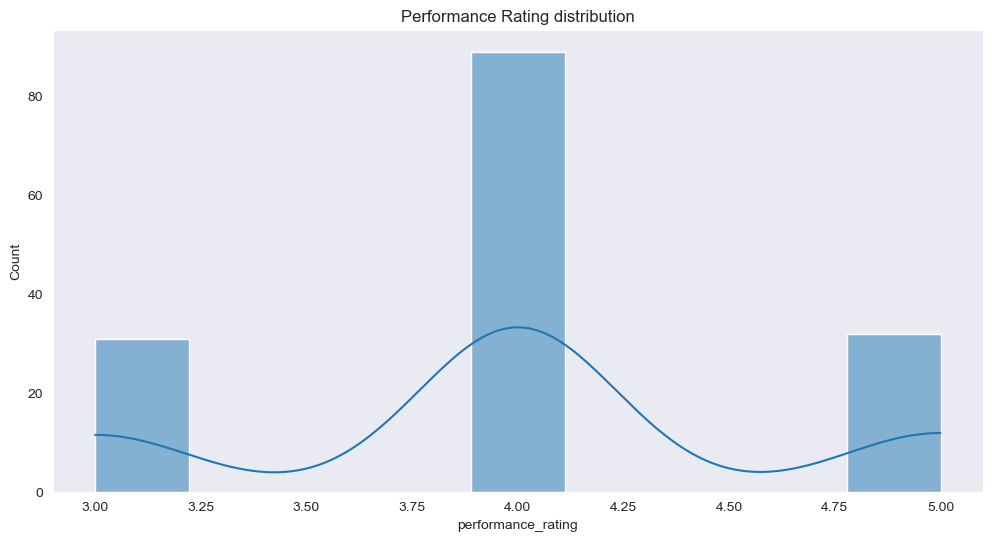

In [141]:
#Performance distribution

sns.histplot(Em['performance_rating'],kde=True)
plt.title('Performance Rating distribution')
plt.show()

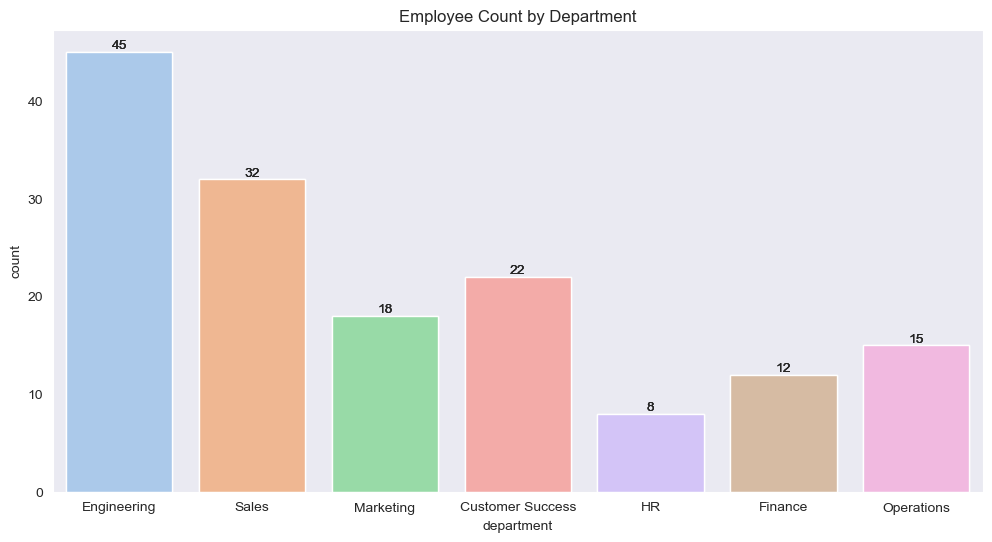

In [139]:
#Employee by department

ax=sns.countplot(x=Em['department'],palette='pastel')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Employee Count by Department')
plt.show()

In [145]:
Tn.columns

Index(['employee_id', 'department', 'termination_date', 'reason',
       'tenure_months'],
      dtype='object')

In [147]:
Em.columns

Index(['employee_id', 'department', 'hire_date', 'tenure_months', 'salary',
       'performance_rating', 'remote_status'],
      dtype='object')

In [151]:
Total_Employee = Em['employee_id'].count()
Total_Employee

152

In [163]:
terminated_Employee = Tn['employee_id'].count()
terminated_Employee

26

In [165]:
Overall_Termination_Rate = (terminated_Employee/Total_Employee)*100
print(f" Overall Termination Rate: {round(Overall_Termination_Rate,2)}%")

 Overall Termination Rate: 17.11%


In [167]:
Hc.head()

,date,department,hires,terminations,starting_headcount,ending_headcount,attrition_rate,growth_rate
0,2023-01-01,Engineering,0,0,45,45,0.0,0.0
1,2023-01-01,Sales,0,0,32,32,0.0,0.0
2,2023-01-01,Marketing,0,0,18,18,0.0,0.0
3,2023-01-01,Customer Success,0,0,22,22,0.0,0.0
4,2023-01-01,HR,0,0,8,8,0.0,0.0


In [169]:
Hc.shape

(126, 8)

In [177]:
Hc['date']

0     2023-01-01
1     2023-01-01
2     2023-01-01
3     2023-01-01
4     2023-01-01
         ...    
121   2024-06-01
122   2024-06-01
123   2024-06-01
124   2024-06-01
125   2024-06-01
Name: date, Length: 126, dtype: datetime64[ns]

In [179]:
#Attrition by Month
Hc['date_month']=pd.to_datetime(Hc['date']).dt.month

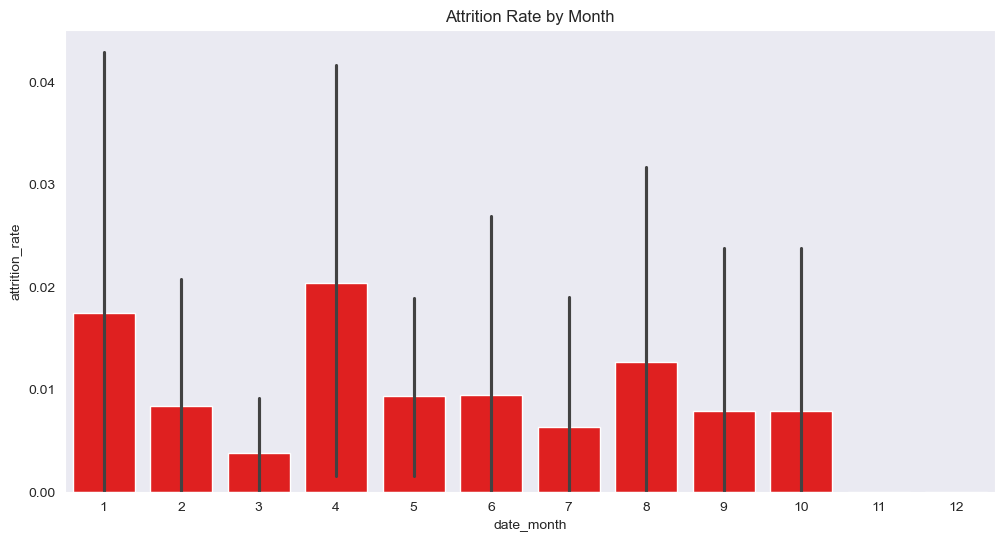

In [203]:
sns.barplot(x='date_month',y='attrition_rate',data=Hc,errorbar=('ci', 95),color='red')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attrition Rate by Month')
plt.show()

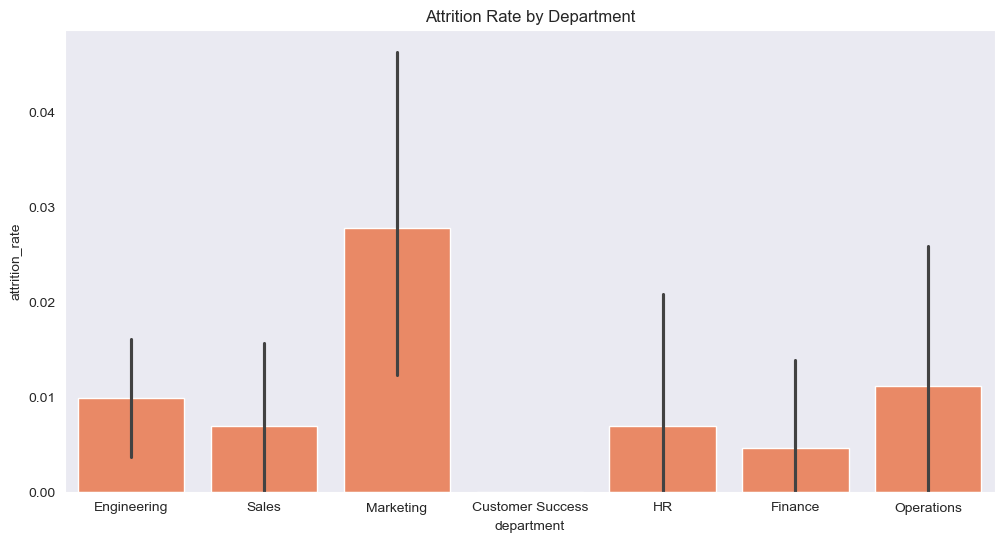

In [207]:
sns.barplot(x='department',y='attrition_rate',data=Hc,errorbar=('ci', 95),color='coral')
for bars in ax.containers:
    ax.bar_label(bars)
plt.title('Attrition Rate by Department')
plt.show()

In [209]:
Hr.head()

,employee_id,department,hire_date,salary,source
0,1152,HR,2023-02-11,87216.865771,Referral
1,1153,HR,2023-11-13,87760.661047,LinkedIn
2,1154,Customer Success,2024-02-18,107761.593076,Referral


In [219]:
Hired_source = Hr.groupby('source',as_index=False).size()
Hired_source

,source,size
0,LinkedIn,1
1,Referral,2


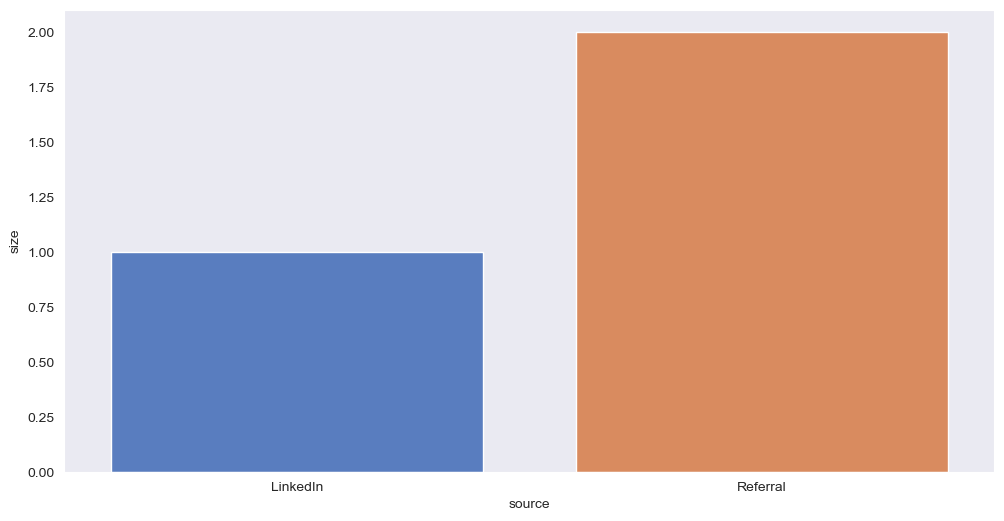

In [229]:
sns.barplot(Hired_source,x='source',y='size',palette='muted')
plt.show()

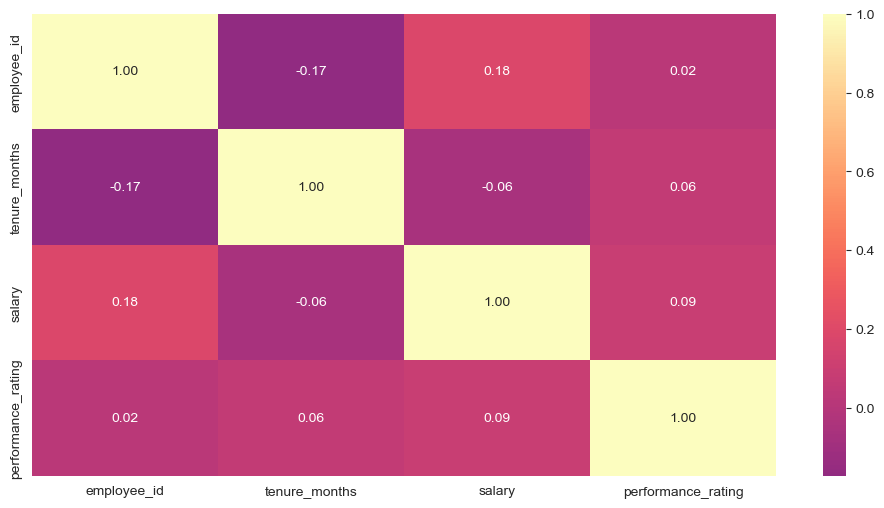

In [241]:
corr_matrix = Em.corr(numeric_only=True)

sns.heatmap(corr_matrix,annot=True,cmap='magma',fmt=".2f",center=0)
plt.show()

In [251]:
top_2_feature = corr_matrix.reindex(corr_matrix.abs().index)[:2]
top_2_feature

,employee_id,tenure_months,salary,performance_rating
employee_id,1.000000,-0.173203,0.179806,0.022476
tenure_months,-0.173203,1.000000,-0.063453,0.057134


## Observation:3 

1. Most hired through `Referral`
2. `Marketing` Department has highes Attriation Rate
3. Overall Attrition rate is `17.11%`
4. `Engineering` Department has more Employee
5. Employee got Average performance rating of `4`
6. Tenure Months is highly corelated with Employee `-0.17`

## Case Study Analysis

In [257]:
Hc.columns

Index(['date', 'department', 'hires', 'terminations', 'starting_headcount',
       'ending_headcount', 'attrition_rate', 'growth_rate', 'date_month'],
      dtype='object')

In [269]:
# Rolling Avg(trend_analysis)

monthly_Hc = Hc.sort_values(['department','date'])
monthly_Hc['avg_3_m_avg']=Hc.groupby('department')['attrition_rate'].rolling(window=3,min_periods=1).mean().reset_index(0,drop=True)
monthly_Hc['headcount_change']=monthly_Hc.groupby('department')['ending_headcount'].diff()
monthly_Hc['headcount_change']

3      NaN
10     0.0
17     0.0
24     0.0
31     0.0
      ... 
92    -2.0
99     1.0
106    1.0
113    0.0
120    0.0
Name: headcount_change, Length: 126, dtype: float64